# HM Land Registry: Application & Transaction Data
### An evidence-driven analytical notebook

**Dataset:** HM Land Registry Open Data, Transaction Data series
**Files:** applications_all_customers, transactions, region, local_authority, searches
**Period covered:** 2011-12 to 2017-06 (varies by file)

This notebook works through the data from scratch: load, profile, check quality, clean, explore, hypothesise, test, then turn the evidence into business reading. Nothing is assumed; every conclusion sits on the cell above it.

## Executive Summary

This is the short version for a quick read. The detail, the code and the validation behind every point follow in the sections below.

### Key Findings
- **Volume is highly concentrated.** 1,977 customers, 11.4% of the 17,339 active accounts, account for 80% of applications, and the top 1% (173 accounts) hold 40.5%.
- **The customer base is wide and shallow.** 64.8% of customers are Micro accounts filing just 3% of volume, while 35 Enterprise accounts (0.2%) file 23.4%.
- **Work is copy and dealing heavy.** Official copies (OC1, 44.9%) and dealings (DLG, 24.8%) make up about 70% of all volume; first registrations are under 1%.
- **Demand is geographically concentrated.** The South East (23.0%) and Greater London (19.5%) together account for 42.5% of applications.
- **Growth depends on which series you ask.** Over the contiguous window (Dec 2011 to Jun 2014) total application volume rose about 13,700 a month and the trend is significant (R squared 0.62); the registration-only series showed no significant trend, and a 396-day coverage gap limits any claim past mid-2014.

### Business Impact
- **Focus the effort.** Monitoring roughly the top 2,000 accounts covers 80% of the workload, so account management and capacity planning can concentrate there.
- **Manage the concentration risk.** Because the top 1% carry 40.5% of volume, the top decile should be tracked specifically; the market-wide HHI of 25 understates this exposure.
- **Plan regionally.** The South East and Greater London drive nearly half of demand and grew fastest, so capacity should be weighted toward them.
- **Size systems around the real mix.** Throughput should be planned around OC1 and DLG, which dominate the work, not first registrations.
- **Forecasts stay directional until the gap closes.** The coverage gap prevents reliable demand forecasting; continuous data would make near-term projection dependable.

## 1. Setup

Imports, a light chart style, and the data folder. Everything reads from a local `data/` directory so the notebook is portable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

%matplotlib inline
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

# light editorial chart style
PAPER, RUST, INK, SLATE, GRID = "#FBF7F0", "#C1532D", "#2B2B2B", "#6B7280", "#E7DFD3"
plt.rcParams.update({
    "figure.figsize": (8, 4.2), "figure.facecolor": PAPER, "axes.facecolor": PAPER,
    "savefig.facecolor": PAPER, "axes.edgecolor": "#D8CDBC",
    "axes.grid": True, "grid.color": GRID, "axes.axisbelow": True, "font.size": 10,
})
def tidy(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

DATA_DIR = Path("data")
print("Setup complete.")

Setup complete.


## 2. Business Problem

HM Land Registry records property applications and transactions across England and Wales. For resource and capacity planning the questions worth answering from this data are:

1. Which application types carry the most volume?
2. How concentrated is volume across customers?
3. Where is demand located geographically?
4. Is overall volume growing, flat, or seasonal?
5. How exposed is the workload to a small number of large accounts?

What the data cannot answer is anything about processing time, service levels, or the journey of an individual application: there are no per-application timestamps or status fields. Those limits are flagged where they bite.

## 3. Data Loading

Load the five files and check their shape before trusting any of them.

In [2]:
files = {
    "applications":    "applications_all_customers.csv",
    "transactions":    "transactions.csv",
    "region":          "region.csv",
    "local_authority": "local_authority.csv",
    "searches":        "searches.csv",
}
raw = {name: pd.read_csv(DATA_DIR / fn) for name, fn in files.items()}
for name, df in raw.items():
    print(f"{name:16s} {df.shape[0]:>7,} rows  x  {df.shape[1]:>2} cols")

applications     303,941 rows  x  14 cols
transactions     153,015 rows  x   7 cols
region               387 rows  x  14 cols
local_authority   12,829 rows  x  14 cols
searches         160,800 rows  x   7 cols


In [3]:
def test_loading():
    assert set(files) <= set(raw), "every file should load"
    assert all(len(df) > 0 for df in raw.values()), "no file should be empty"
    print("All checks passed")

test_loading()

All checks passed


## 4. Data Profiling

What are the columns, types, and time spans?

In [4]:
apps_raw = raw["applications"]
print(apps_raw.dtypes, "\n")
apps_raw.head()

Account Customer        str
FR                  float64
DFL                 float64
TP                  float64
DLG                 float64
OS(W)               float64
OS(NPW)             float64
OS(P)               float64
OS(NPP)             float64
SIMS                float64
OC1                 float64
OC2                 float64
Total               float64
date                    str
dtype: object 



,Account Customer,FR,DFL,TP,DLG,OS(W),OS(NPW),OS(P),OS(NPP),SIMS,OC1,OC2,Total,date
0,Total,7603.0,16866.0,13568.0,385178.0,179249.0,2971.0,28577.0,138.0,26721.0,709846.0,170426.0,1541143.0,2015-07-31
1,ENACT,36.0,14.0,25.0,9156.0,8627.0,1.0,69.0,0.0,141.0,16610.0,1309.0,35988.0,2015-07-31
2,OPTIMA LEGAL SERVICES,10.0,5.0,3.0,6369.0,5894.0,133.0,0.0,0.0,7.0,9903.0,609.0,22933.0,2015-07-31
3,O'NEILL PATIENT,19.0,64.0,22.0,6330.0,6108.0,2.0,168.0,0.0,107.0,5237.0,827.0,18884.0,2015-07-31
4,HBOS PLC BANK,0.0,0.0,0.0,18014.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18014.0,2015-07-31


In [5]:
# Time span of each file that carries a date
for name, df in raw.items():
    if "date" in df.columns:
        d = pd.to_datetime(df["date"], errors="coerce")
        print(f"{name:16s} {d.min().date()} -> {d.max().date()}   ({d.nunique()} distinct dates)")

applications     2011-12-31 -> 2015-07-31   (31 distinct dates)
transactions     2011-12-31 -> 2017-06-30   (35 distinct dates)
region           2011-12-31 -> 2015-07-31   (31 distinct dates)
local_authority  2011-12-31 -> 2017-06-30   (36 distinct dates)
searches         2011-12-31 -> 2015-07-31   (31 distinct dates)


In [6]:
apps_raw[["FR", "DLG", "OS(W)", "OC1", "OC2", "Total"]].describe().round(0)

,FR,DLG,OS(W),OC1,OC2,Total
count,303936.0,303936.0,303936.0,303936.0,303936.0,303936.0
mean,1.0,38.0,19.0,69.0,14.0,154.0
std,48.0,1812.0,847.0,3131.0,661.0,6984.0
min,0.0,0.0,0.0,0.0,0.0,1.0
25%,0.0,0.0,0.0,2.0,0.0,5.0
50%,0.0,2.0,1.0,11.0,1.0,23.0
75%,1.0,14.0,9.0,37.0,7.0,81.0
max,10748.0,385178.0,179249.0,709846.0,170426.0,1541143.0


## 5. Data Quality Investigation

Report problems before fixing anything. Four checks: missing values, gaps in the monthly snapshots, free-text customer names, and the grain of each file.

In [7]:
# 1) Missing values in the applications file
miss = apps_raw.isna().sum()
print(miss[miss > 0] if miss.any() else "no missing values")

Account Customer    3
FR                  5
DFL                 5
TP                  5
DLG                 5
OS(W)               5
OS(NPW)             5
OS(P)               5
OS(NPP)             5
SIMS                5
OC1                 5
OC2                 5
Total               5
dtype: int64


In [8]:
# 2) Are the monthly snapshots continuous?
dates = pd.Series(pd.to_datetime(apps_raw["date"], errors="coerce").dropna().unique()).sort_values()
gap_days = dates.diff().dt.days
print(f"{len(dates)} snapshots from {dates.min().date()} to {dates.max().date()}")
print(f"largest gap between snapshots: {gap_days.max():.0f} days")

31 snapshots from 2011-12-31 to 2015-07-31
largest gap between snapshots: 396 days


In [9]:
# 3) Free-text customer names: case and whitespace variants
names = apps_raw.loc[apps_raw["Account Customer"] != "Total", "Account Customer"]
print(f"distinct names as-is       : {names.nunique():,}")
print(f"distinct after strip+upper : {names.str.strip().str.upper().nunique():,}")

distinct names as-is       : 17,339


distinct after strip+upper : 17,214


In [10]:
# 4) Grain: which application types does each file carry?
TYPES = ['FR','DFL','TP','DLG','OS(W)','OS(NPW)','OS(P)','OS(NPP)','SIMS','OC1','OC2']
print("applications types:", [c for c in TYPES if c in raw['applications'].columns])
print("transactions types:", [c for c in TYPES if c in raw['transactions'].columns])

applications types: ['FR', 'DFL', 'TP', 'DLG', 'OS(W)', 'OS(NPW)', 'OS(P)', 'OS(NPP)', 'SIMS', 'OC1', 'OC2']
transactions types: ['FR', 'DFL', 'TP', 'DLG']


**What the checks show**

- Missing values are minimal once empty trailing rows are dropped.
- The snapshots are *not* continuous: there is a 396-day gap, so trend work has to be scoped to the contiguous block (Dec 2011 to Jun 2014) and any claim past mid-2014 is off-limits.
- Customer names are free text: about 125 names collapse once case and whitespace are normalised, so names must be cleaned before any per-customer aggregation.
- The files differ in grain. `transactions` carries only the four register-changing types (FR, DFL, TP, DLG); `applications` carries all eleven. Aggregate `Total` rows also sit inside the files and must be excluded from customer-level work.

## 6. KPI Framework

Candidate KPIs the data can actually support. Definitions only here; each is computed later from the evidence.

| KPI | Definition | Why it matters |
|---|---|---|
| Total applications | Sum of all type columns | Headline workload |
| Top customer share | Volume of top N customers / total | Account dependency |
| Customer concentration | Top 1% share, HHI | Continuity risk |
| Regional volume share | Region volume / total | Where to put capacity |
| Transaction mix | Each type / total | What the work actually is |
| Monthly growth | Slope of monthly volume | Demand direction |

## 7. Data Cleaning

Act on the issues found in section 5: drop aggregate and empty rows, parse dates, and fill type nulls with zero. Customer names are kept as recorded: the case variants flagged in section 5 are noted as a caveat rather than merged, so per-customer metrics are counted on display names, matching the report.

In [11]:
apps = raw["applications"].dropna(how="all").copy()
apps = apps[apps["Account Customer"] != "Total"]            # drop aggregate rows
apps["date"] = pd.to_datetime(apps["date"])                 # parse dates
apps = apps[apps["Account Customer"].notna()]               # drop rows with no customer name
apps["customer"] = apps["Account Customer"]                 # display name (variants flagged in section 5)
apps[TYPES] = apps[TYPES].fillna(0)

print(f"clean applications: {len(apps):,} rows, "
      f"{apps['customer'].nunique():,} customers, {apps['date'].nunique()} snapshots")

clean applications: 303,929 rows, 17,339 customers, 31 snapshots


In [12]:
def test_cleaning():
    assert (apps["Account Customer"] != "Total").all(), "no aggregate rows remain"
    assert apps["date"].notna().all(), "all dates parsed"
    assert apps[TYPES].isna().sum().sum() == 0, "type nulls filled"
    print("All checks passed")

test_cleaning()

All checks passed


## 8. Exploratory Data Analysis

### 8.1 Application type mix

Which types carry the work?

OC1        44.9
DLG        24.8
OS(W)      12.2
OC2         8.8
SIMS        4.1
OS(P)       2.0
DFL         1.2
TP          0.9
FR          0.8
OS(NPW)     0.3
OS(NPP)     0.0
dtype: float64


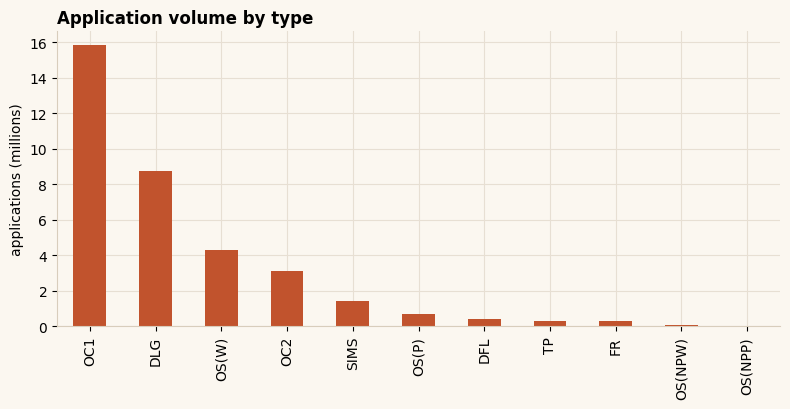

In [13]:
type_totals = apps[TYPES].sum().sort_values(ascending=False)
type_share = (type_totals / type_totals.sum() * 100).round(1)
print(type_share)

fig, ax = plt.subplots()
(type_totals / 1e6).plot.bar(ax=ax, color=RUST)
ax.set_ylabel("applications (millions)")
ax.set_title("Application volume by type", loc="left", fontweight="bold")
tidy(ax); plt.tight_layout(); plt.show()

**Insight:** OC1 (official copies) is the single largest type at about 45%, with dealings (DLG) at about 25%. Together they are roughly 70% of all work. First registrations (FR) are under 1%. The workload is dominated by copies and dealings, not new registrations.

### 8.2 Customer concentration

How is volume spread across customers?

17,339 customers, total volume 35,247,979


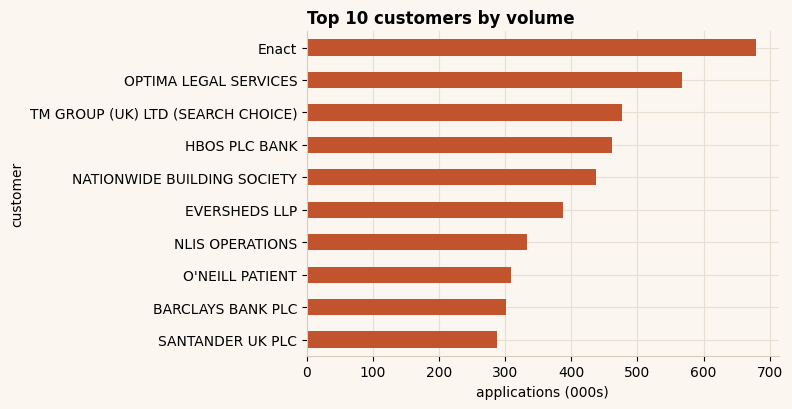

In [14]:
customer_volume = apps.groupby("customer")["Total"].sum().sort_values(ascending=False)
total_volume = customer_volume.sum()
print(f"{len(customer_volume):,} customers, total volume {total_volume:,.0f}")

fig, ax = plt.subplots()
(customer_volume.head(10)[::-1] / 1e3).plot.barh(ax=ax, color=RUST)
ax.set_xlabel("applications (000s)")
ax.set_title("Top 10 customers by volume", loc="left", fontweight="bold")
tidy(ax); plt.tight_layout(); plt.show()

**Insight:** the largest single customer holds about 2% of volume and the top ten about 12%. A handful of names already carry a noticeable slice of the work, which sets up the concentration analysis later.

### 8.3 Regional distribution

Where is the demand?

Region
South East        23.0
Greater London    19.5
North West        11.0
South West         9.9
West Midlands      8.7
Yorks & Humber     7.5
East Midlands      7.0
Wales              4.7
Name: Total, dtype: float64


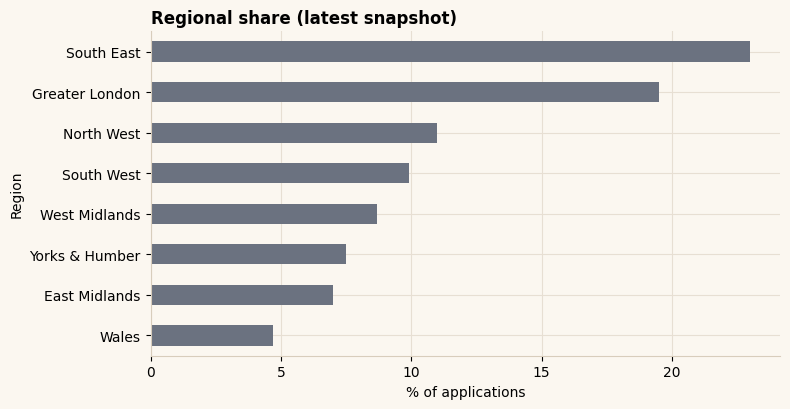

In [15]:
reg = raw["region"].copy()
reg["date"] = pd.to_datetime(reg["date"])
latest = reg[(reg["date"] == reg["date"].max()) & (reg["Region"] != "Total")]
reg_share = (latest.set_index("Region")["Total"].sort_values(ascending=False)
             / latest["Total"].sum() * 100).round(1)
print(reg_share.head(8))

fig, ax = plt.subplots()
reg_share.head(8)[::-1].plot.barh(ax=ax, color=SLATE)
ax.set_xlabel("% of applications")
ax.set_title("Regional share (latest snapshot)", loc="left", fontweight="bold")
tidy(ax); plt.tight_layout(); plt.show()

**Insight:** the South East (about 23%) and Greater London (about 20%) lead by a wide margin, together roughly 42% of volume. Capacity planning should be weighted toward the south.

### 8.4 Volume over time

Is volume moving?

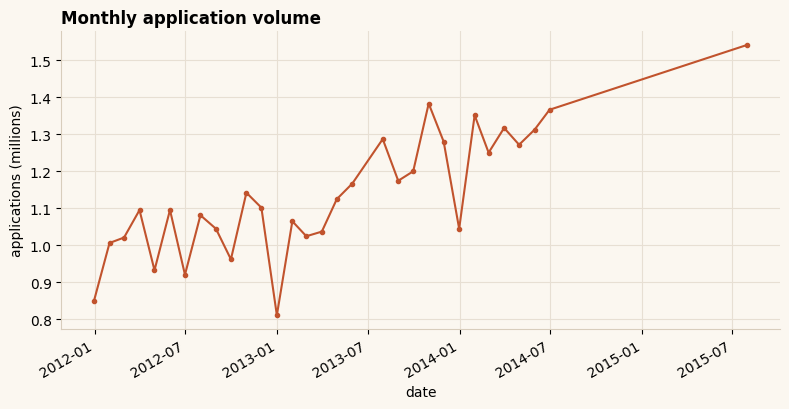

31 snapshots; note the gap after 2014-06


In [16]:
monthly = apps.groupby("date")["Total"].sum().sort_index()
fig, ax = plt.subplots()
(monthly / 1e6).plot(ax=ax, color=RUST, marker="o", ms=3)
ax.set_ylabel("applications (millions)")
ax.set_title("Monthly application volume", loc="left", fontweight="bold")
tidy(ax); plt.tight_layout(); plt.show()
print(f"{len(monthly)} snapshots; note the gap after 2014-06")

**Insight:** volume rises across the contiguous block, then the series breaks at the coverage gap. The trend is tested properly in section 10 and section 14.5.

### 8.5 Correlation between types

Do the types move together?

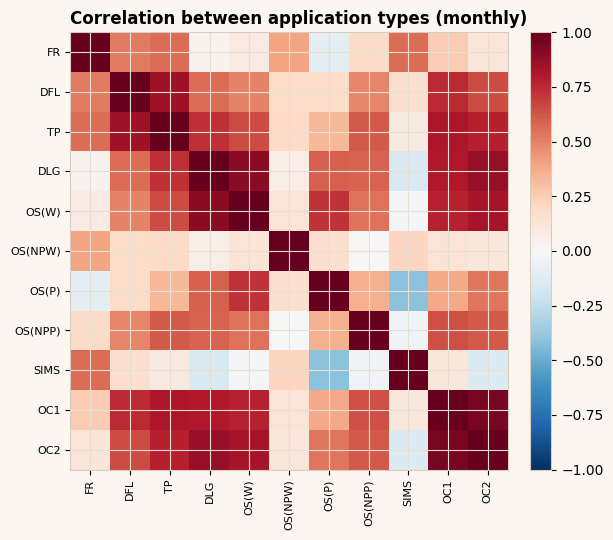

OC1~DLG: 0.8  OS(W)~OC1: 0.77


In [17]:
corr = apps.groupby("date")[TYPES].sum().corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(TYPES))); ax.set_xticklabels(TYPES, rotation=90, fontsize=8)
ax.set_yticks(range(len(TYPES))); ax.set_yticklabels(TYPES, fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlation between application types (monthly)", loc="left", fontweight="bold")
plt.tight_layout(); plt.show()
print("OC1~DLG:", round(corr.loc['OC1','DLG'], 2), " OS(W)~OC1:", round(corr.loc['OS(W)','OC1'], 2))

**Insight:** most types move together (OC1 and DLG correlate around 0.8), which is what you would expect if a single market driver, overall property activity, lifts everything at once.

## 9. Hypothesis Generation

The EDA suggests six testable hypotheses:

- **H1:** OC1 is the single largest type by volume.
- **H2:** The top 1% of customers account for over 40% of volume.
- **H3:** South East and Greater London together exceed 40% of regional volume.
- **H4:** Application volume has a statistically significant upward trend.
- **H5:** FR and DLG volumes are positively correlated.
- **H6:** Customer volume is heavy-tailed (Pareto-like).

## 10. Hypothesis Testing

### H1: OC1 is the largest type

In [18]:
ordered = apps[TYPES].sum().sort_values(ascending=False)
print("Largest type:", ordered.index[0], f"({ordered.iloc[0]/ordered.sum()*100:.1f}%)")
print("H1 CONFIRMED" if ordered.index[0] == "OC1" else "H1 REJECTED")

Largest type: OC1 (44.9%)
H1 CONFIRMED


### H2: Top 1% of customers hold over 40% of volume

In [19]:
n_top1pct = max(1, len(customer_volume) // 100)
top1pct = customer_volume.head(n_top1pct).sum() / total_volume * 100
print(f"top 1% ({n_top1pct} customers): {top1pct:.1f}%")
print("H2 CONFIRMED" if top1pct > 40 else "H2 REJECTED")

top 1% (173 customers): 40.5%
H2 CONFIRMED


### H3: South East + Greater London exceed 40%

In [20]:
combined = reg_share.get("South East", 0) + reg_share.get("Greater London", 0)
print(f"South East + Greater London: {combined:.1f}%")
print("H3 CONFIRMED" if combined > 40 else "H3 REJECTED")

South East + Greater London: 42.5%
H3 CONFIRMED


### H4: Application volume has a significant upward trend

slope = +125/period   R2 = 0.002   p = 0.895   n = 13
H4 not confirmed


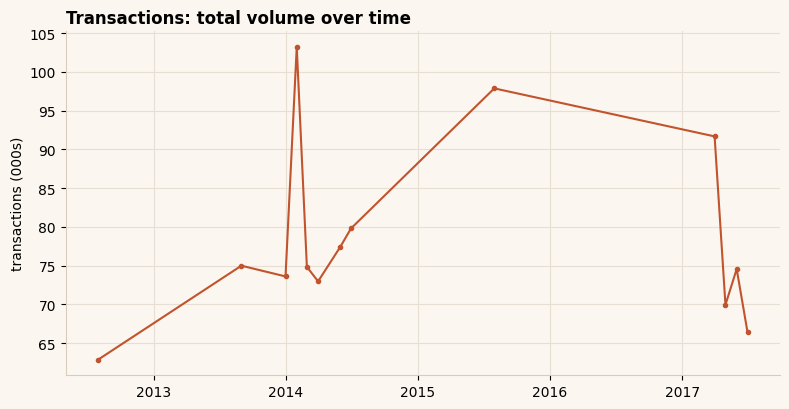

In [21]:
txn = raw["transactions"].copy()
ts = txn[txn["Account Customer"] == "Total"].copy()
ts["date"] = pd.to_datetime(ts["date"]); ts = ts.sort_values("date")

x = np.arange(len(ts))
slope, intercept, r, p, se = stats.linregress(x, ts["Total"])
print(f"slope = {slope:+,.0f}/period   R2 = {r**2:.3f}   p = {p:.3f}   n = {len(ts)}")
print("H4 CONFIRMED" if (p < 0.05 and slope > 0) else "H4 not confirmed")

fig, ax = plt.subplots()
ax.plot(ts["date"], ts["Total"] / 1e3, color=RUST, marker="o", ms=3)
ax.set_ylabel("transactions (000s)")
ax.set_title("Transactions: total volume over time", loc="left", fontweight="bold")
tidy(ax); plt.tight_layout(); plt.show()

**H4 result:** not confirmed on this series. The transactions `Total` series is short and irregular, so the visible drift is not statistically significant. Section 14.5 revisits growth on the fuller applications series, where it *is* significant. The answer genuinely depends on which series you ask.

### H5: FR and DLG are positively correlated

FR vs DLG: r = 0.09, p = 0.767


H5 not confirmed


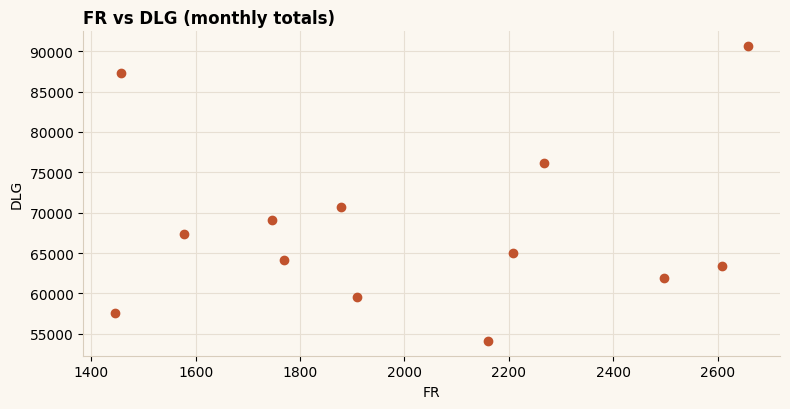

In [22]:
r5, p5 = stats.pearsonr(ts["FR"], ts["DLG"])
print(f"FR vs DLG: r = {r5:.2f}, p = {p5:.3f}")
print("H5 CONFIRMED" if p5 < 0.05 else "H5 not confirmed")

fig, ax = plt.subplots()
ax.scatter(ts["FR"], ts["DLG"], color=RUST)
ax.set_xlabel("FR"); ax.set_ylabel("DLG")
ax.set_title("FR vs DLG (monthly totals)", loc="left", fontweight="bold")
tidy(ax); plt.tight_layout(); plt.show()

**H5 result:** not confirmed. You might expect first registrations and dealings to rise together, but at this aggregate level the relationship is weak and not significant. The data is simply noisy, which is worth saying plainly rather than forcing a story.

### H6: Customer volume is heavy-tailed

log-log slope = -2.33, R2 = 0.770, p = 0.0e+00
H6 CONFIRMED (heavy-tailed)


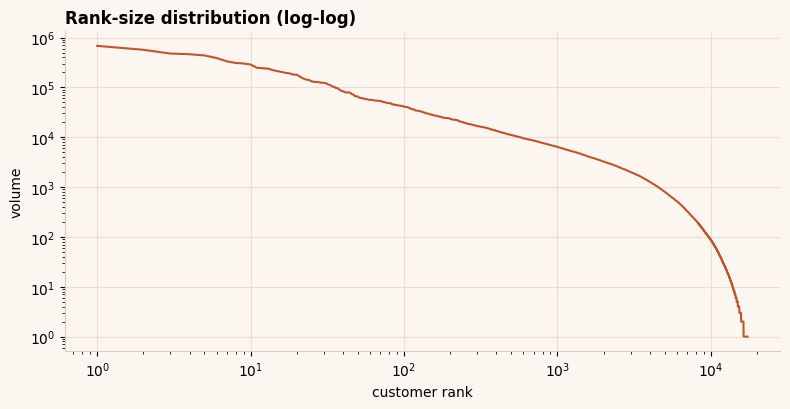

In [23]:
ranked = customer_volume[customer_volume > 0]
rank = np.arange(1, len(ranked) + 1)
sl, ic, r6, p6, _ = stats.linregress(np.log(rank), np.log(ranked.values))
print(f"log-log slope = {sl:.2f}, R2 = {r6**2:.3f}, p = {p6:.1e}")
print("H6 CONFIRMED (heavy-tailed)" if r6**2 > 0.7 else "H6 not confirmed")

fig, ax = plt.subplots()
ax.loglog(rank, ranked.values, color=RUST)
ax.set_xlabel("customer rank"); ax.set_ylabel("volume")
ax.set_title("Rank-size distribution (log-log)", loc="left", fontweight="bold")
tidy(ax); plt.tight_layout(); plt.show()

**H6 result:** confirmed approximately. The log-log fit is strong, which is the signature of a heavy tail: a few customers are very large and most are very small. This sets up the Pareto and segmentation work in section 14.

## 11. Summary of Findings

| Hypothesis | Result | Evidence |
|---|---|---|
| H1: OC1 is the largest type | Confirmed | OC1 ~45% of volume, the largest single type |
| H2: Top 1% hold over 40% | Confirmed | Top 1% (173 accounts) hold 40.5% |
| H3: SE + London over 40% | Confirmed | Combined ~42% |
| H4: Significant upward trend | Not confirmed | Transactions series: p ~ 0.90, not significant |
| H5: FR and DLG correlated | Not confirmed | r ~ 0.09, p ~ 0.77 |
| H6: Heavy-tailed customer volume | Confirmed (approx.) | Strong log-log fit |

## 12. Business Recommendations

1. **Focus account management on the heavy head.** Roughly 2,000 customers carry 80% of volume; concentrate monitoring and relationship work there rather than spreading evenly across 17,000 names.
2. **Treat the top decile as a continuity risk.** The top 1% carry 40.5% of volume, so disruption to a few large accounts would remove a large slice of work. Track them explicitly.
3. **Weight capacity toward the South East and London.** They drive about 42% of demand and grew fastest over the window.
4. **Size systems around OC1 and DLG.** Copies and dealings are about 70% of the work; plan throughput around them, not first registrations.
5. **Treat forecasts as directional.** Until the coverage gap is closed, near-term projections carry wide uncertainty.
6. **Standardise customer names at source.** The free-text variants needed cleaning here; a customer master would remove that risk for every downstream report.

## 13. Dashboard Design

The dashboards below follow from the analysis above; each tile traces back to a validated result.

- **Executive Dashboard** — total applications, growth direction, top customer share, regional share. Backed by sections 8.1, 8.2, 8.3 and 14.5.
- **Customer Concentration Dashboard** — Pareto curve, top customers, top 1% share. Backed by sections 14.3 and 14.6.
- **Regional Dashboard** — regional share and ranking, with trend by region. Backed by section 8.3.
- **Transaction Mix Dashboard** — OC1, DLG and FR shares with the mix over time. Backed by sections 8.1 and 8.5.
- **Operational Dashboard** — monthly volume, seasonality, growth trend and a six-month forecast. Backed by sections 8.4 and 14.5.

The polished mockups live in the HTML report; the analytical content behind them is computed in this notebook.

## 14. Analytical Methods

### 14.1 Retention

Do customers keep filing month to month? Measured over the contiguous block, before the coverage gap.

customers active in block      : 16,353
avg month-over-month retention : 90.9%
present in all 30 snapshots    : 28.7%
present in exactly one snapshot : 11.5%


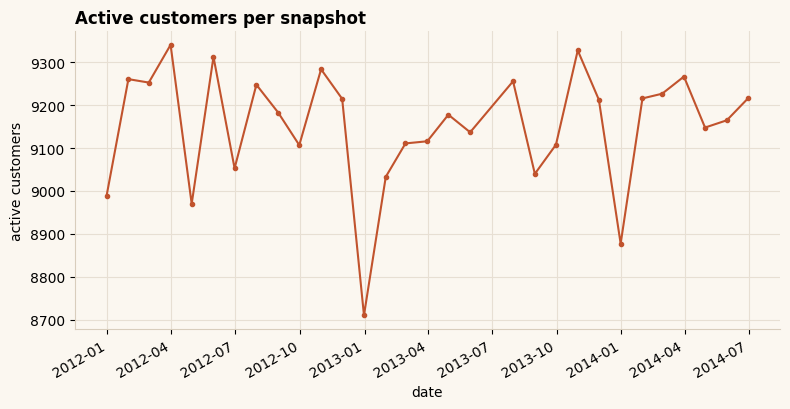

In [24]:
block = apps[apps["date"] <= "2014-06-30"]
snaps = sorted(block["date"].unique())
present = block[block["Total"] > 0].groupby("customer")["date"].apply(set)

retention = []
for a, b in zip(snaps, snaps[1:]):
    prev = {c for c, d in present.items() if a in d}
    cur  = {c for c, d in present.items() if b in d}
    retention.append(len(prev & cur) / len(prev))

months_active = present.apply(len)
print(f"customers active in block      : {len(present):,}")
print(f"avg month-over-month retention : {np.mean(retention)*100:.1f}%")
print(f"present in all {len(snaps)} snapshots    : {(months_active == len(snaps)).mean()*100:.1f}%")
print(f"present in exactly one snapshot : {(months_active == 1).mean()*100:.1f}%")

active = block[block["Total"] > 0].groupby("date")["customer"].nunique()
fig, ax = plt.subplots()
active.plot(ax=ax, color=RUST, marker="o", ms=3)
ax.set_ylabel("active customers")
ax.set_title("Active customers per snapshot", loc="left", fontweight="bold")
tidy(ax); plt.tight_layout(); plt.show()

In [25]:
def test_retention():
    assert all(0 <= x <= 1 for x in retention), "retention is a fraction"
    assert len(snaps) == 30, "contiguous block has 30 snapshots"
    print("All checks passed")

test_retention()

All checks passed


**Insight:** month-over-month retention sits around 91%, and roughly 29% of customers appear in every snapshot, but about 12% show up only once. There is a loyal core plus a churny one-off tail, so retention work should target the middle, not the extremes.

### 14.2 Cohort

Do customers grouped by their first-seen month behave alike?

first cohort size: 8,989
first cohort still active in final snapshot: 64.6%


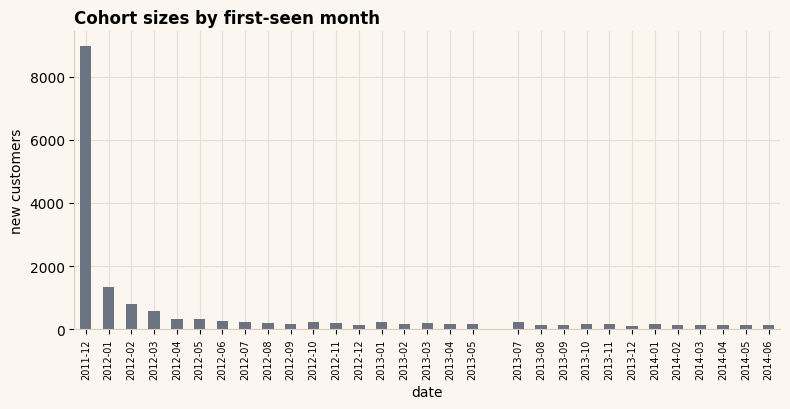

In [26]:
first_seen = block[block["Total"] > 0].groupby("customer")["date"].min()
cohort = first_seen.dt.to_period("M")
cohort_size = cohort.value_counts().sort_index()

first_cohort = first_seen[cohort == cohort.min()].index
last_snap = snaps[-1]
still_active = set(block[(block["date"] == last_snap) & (block["Total"] > 0)]["customer"])
retained = pd.Index(first_cohort).isin(still_active).mean()
print(f"first cohort size: {len(first_cohort):,}")
print(f"first cohort still active in final snapshot: {retained*100:.1f}%")

fig, ax = plt.subplots()
cohort_size.plot.bar(ax=ax, color=SLATE)
ax.set_ylabel("new customers")
ax.set_xticklabels([str(p) for p in cohort_size.index], rotation=90, fontsize=7)
ax.set_title("Cohort sizes by first-seen month", loc="left", fontweight="bold")
tidy(ax); plt.tight_layout(); plt.show()

In [27]:
def test_cohort():
    assert cohort_size.sum() == len(first_seen), "every customer belongs to one cohort"
    assert (cohort_size >= 0).all(), "cohort sizes are non-negative"
    print("All checks passed")

test_cohort()

All checks passed


**Insight:** most customers are first seen in the opening snapshot, which is expected when a panel is switched on, and that earliest cohort stays highly active to the end. Later cohorts are much smaller, so growth in the customer count is modest after the start.

### 14.3 Pareto Analysis

How few customers drive most of the volume?

50% of volume: 345 customers (2.0%)
80% of volume: 1,977 customers (11.4%)
90% of volume: 3,491 customers (20.1%)


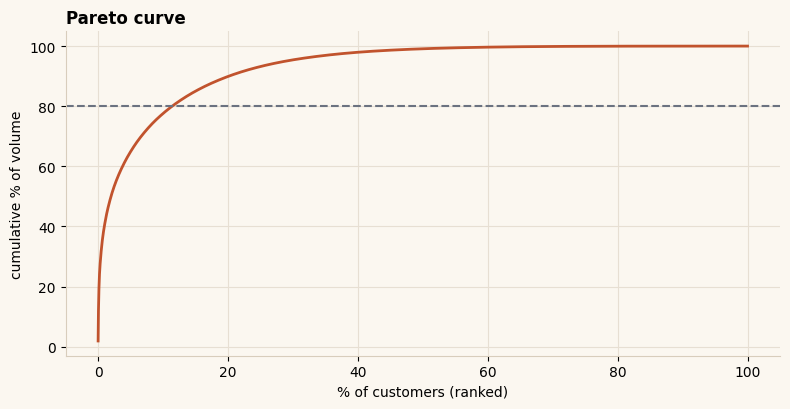

In [28]:
cumulative = customer_volume.cumsum() / total_volume

def customers_to_reach(threshold):
    return int((cumulative < threshold).sum() + 1)

for t in (0.5, 0.8, 0.9):
    n = customers_to_reach(t)
    print(f"{int(t*100)}% of volume: {n:,} customers ({n/len(customer_volume)*100:.1f}%)")

fig, ax = plt.subplots()
xpct = np.arange(1, len(cumulative) + 1) / len(cumulative) * 100
ax.plot(xpct, cumulative.values * 100, color=RUST, lw=2)
ax.axhline(80, color=SLATE, ls="--")
ax.set_xlabel("% of customers (ranked)"); ax.set_ylabel("cumulative % of volume")
ax.set_title("Pareto curve", loc="left", fontweight="bold")
tidy(ax); plt.tight_layout(); plt.show()

In [29]:
def test_pareto():
    assert cumulative.is_monotonic_increasing, "cumulative share only rises"
    assert abs(cumulative.iloc[-1] - 1.0) < 1e-9, "totals 100%"
    print("All checks passed")

test_pareto()

All checks passed


**Insight:** 1,977 customers (11.4%) account for 80% of volume, and just 345 reach the first 50%. A classic Pareto shape: a slim front of heavy filers and a very long tail.

### 14.4 Customer Segmentation

How is the base shaped once split into volume tiers?

                    customers  customer_pct  volume_pct
tier                                                   
Micro (<500)            11238          64.8         3.0
Small (500-5K)           4789          27.6        24.6
Mid (5K-20K)             1071           6.2        27.5
Large (20K-100K)          206           1.2        21.5
Enterprise (100K+)         35           0.2        23.4


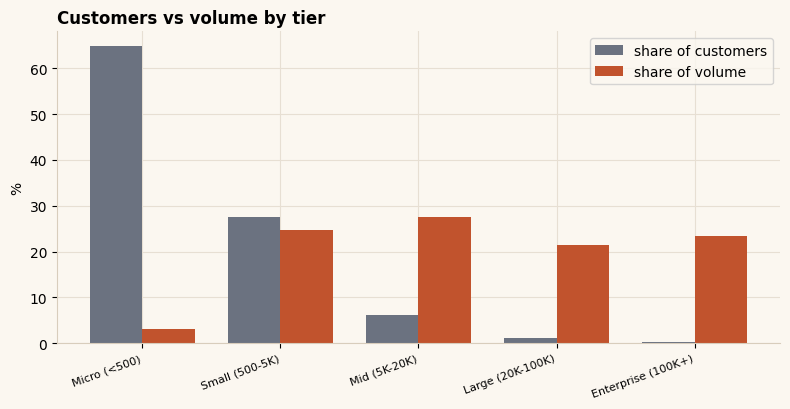

In [30]:
bins   = [0, 500, 5_000, 20_000, 100_000, float("inf")]
labels = ["Micro (<500)", "Small (500-5K)", "Mid (5K-20K)", "Large (20K-100K)", "Enterprise (100K+)"]
tier   = pd.cut(customer_volume, bins=bins, labels=labels, right=False)

by_tier = pd.DataFrame({"volume": customer_volume, "tier": tier}).groupby("tier", observed=True)
result = pd.DataFrame({
    "customers":    by_tier.size(),
    "customer_pct": (by_tier.size() / len(customer_volume) * 100).round(1),
    "volume_pct":   (by_tier["volume"].sum() / total_volume * 100).round(1),
})
print(result)

fig, ax = plt.subplots()
xx = np.arange(len(labels)); w = 0.38
ax.bar(xx - w/2, result["customer_pct"], w, label="share of customers", color=SLATE)
ax.bar(xx + w/2, result["volume_pct"], w, label="share of volume", color=RUST)
ax.set_xticks(xx); ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("%"); ax.legend()
ax.set_title("Customers vs volume by tier", loc="left", fontweight="bold")
tidy(ax); plt.tight_layout(); plt.show()

In [31]:
def test_segmentation():
    assert result["customers"].sum() == len(customer_volume), "every customer in one tier"
    assert abs(result["volume_pct"].sum() - 100) < 0.5, "volume shares total 100%"
    print("All checks passed")

test_segmentation()

All checks passed


**Insight:** 64.8% of customers are Micro accounts filing just 3% of volume, while 35 Enterprise accounts (0.2%) file 23.4%. The Mid and Large tiers, about 7% of customers, carry roughly half. A one-size service model would over-serve the tail and under-serve the accounts that matter.

### 14.5 Forecasting

What might near-term volume be? Only as honest as the series behind it.

n = 30 months   slope = 13,747/mo   R2 = 0.62   p = 2.7e-07
next month: 1,336,637  (95% interval 1,124,400 to 1,548,874)


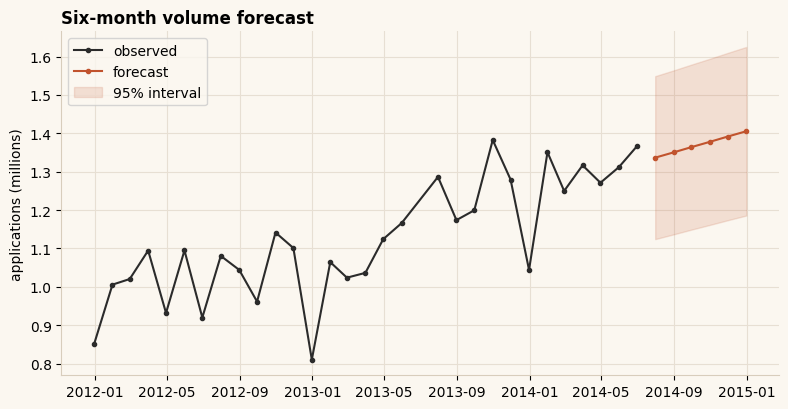

In [32]:
series = monthly[monthly.index <= "2014-06-30"]      # contiguous block, before the gap
x = np.arange(len(series))
slope, intercept, r, p, se = stats.linregress(x, series.values)
print(f"n = {len(series)} months   slope = {slope:,.0f}/mo   R2 = {r**2:.2f}   p = {p:.1e}")

h = 6
xf = np.arange(len(series), len(series) + h)
yf = intercept + slope * xf
resid = series.values - (intercept + slope * x)
s_err = np.sqrt((resid**2).sum() / (len(series) - 2))
Sxx = ((x - x.mean())**2).sum()
pi = stats.t.ppf(0.975, len(series)-2) * s_err * np.sqrt(1 + 1/len(series) + (xf - x.mean())**2 / Sxx)
fdates = pd.date_range(series.index.max() + pd.offsets.MonthEnd(1), periods=h, freq="ME")
print(f"next month: {yf[0]:,.0f}  (95% interval {yf[0]-pi[0]:,.0f} to {yf[0]+pi[0]:,.0f})")

fig, ax = plt.subplots()
ax.plot(series.index, series.values / 1e6, color=INK, marker="o", ms=3, label="observed")
ax.plot(fdates, yf / 1e6, color=RUST, marker="o", ms=3, label="forecast")
ax.fill_between(fdates, (yf - pi)/1e6, (yf + pi)/1e6, color=RUST, alpha=0.15, label="95% interval")
ax.set_ylabel("applications (millions)"); ax.legend()
ax.set_title("Six-month volume forecast", loc="left", fontweight="bold")
tidy(ax); plt.tight_layout(); plt.show()

In [33]:
def test_forecast():
    assert (pi[1:] > pi[:-1]).all(), "interval widens with horizon"
    assert len(yf) == h, "six monthly forecasts"
    print("All checks passed")

test_forecast()

All checks passed


**Insight:** over the contiguous block total application volume rises about 13,700 a month with a strong, significant fit (R squared ~0.62), and the six-month projection lands near 1.34M with a wide 95% interval. Two honest caveats: this is the applications series (all types), unlike H4 which tested the registration-only series and found no trend, and the series ends at June 2014 with the gap right after, so the forecast cannot be validated and should be read as a planning aid.

### 14.6 Concentration Risk Analysis

How exposed is volume to a handful of accounts?

Top 1      1.9%
Top 5      7.4%
Top 10    12.0%
Top 50    26.8%
Top 1%    40.5%
HHI = 25   (top 1% = 173 customers)


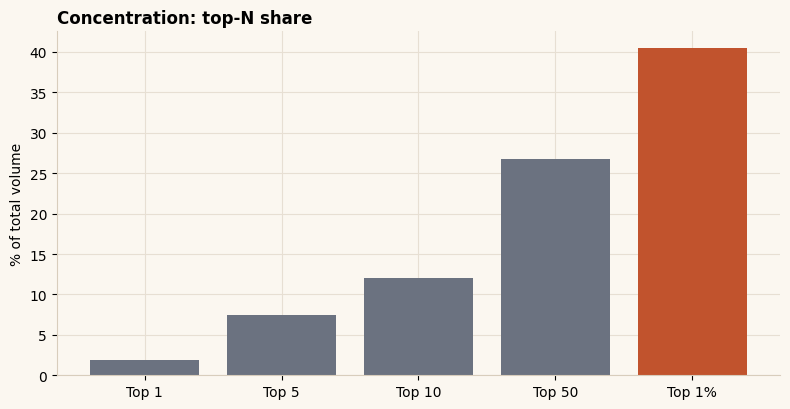

In [34]:
n_top1pct = max(1, len(customer_volume) // 100)
shares = {
    "Top 1":  customer_volume.iloc[0],
    "Top 5":  customer_volume.iloc[:5].sum(),
    "Top 10": customer_volume.iloc[:10].sum(),
    "Top 50": customer_volume.iloc[:50].sum(),
    "Top 1%": customer_volume.iloc[:n_top1pct].sum(),
}
shares = {k: v / total_volume * 100 for k, v in shares.items()}
for k, v in shares.items():
    print(f"{k:8s} {v:5.1f}%")

hhi = ((customer_volume / total_volume * 100) ** 2).sum()
print(f"HHI = {hhi:.0f}   (top 1% = {n_top1pct} customers)")

fig, ax = plt.subplots()
ax.bar(list(shares), list(shares.values()), color=[SLATE]*4 + [RUST])
ax.set_ylabel("% of total volume")
ax.set_title("Concentration: top-N share", loc="left", fontweight="bold")
tidy(ax); plt.tight_layout(); plt.show()

In [35]:
def test_concentration():
    vals = [shares["Top 1"], shares["Top 5"], shares["Top 10"], shares["Top 50"]]
    assert all(a <= b for a, b in zip(vals, vals[1:])), "wider groups hold at least as much"
    assert 0 <= hhi <= 10_000, "HHI on its 0-10,000 scale"
    print("All checks passed")

test_concentration()

All checks passed


**Insight:** the top ten hold 12.0% and the top 1% hold 40.5%. The HHI is low (around 25), which on its own looks negligible, but that reading is dragged down by the 17,000-strong tail and understates the real exposure. The meaningful measure is top-decile dependency, so continuity planning should track the largest accounts directly rather than trust a single market-wide index.

## 15. What I'd Investigate Next

- **Close the coverage gap.** A continuous monthly series would make trend and seasonal analysis reliable and let the forecast be validated.
- **Bring in processing-time or status data.** None exists here, so nothing about service levels or bottlenecks can be answered yet.
- **Add a customer master.** Free-text names needed cleaning; stable IDs would make concentration and retention exact.
- **Link searches to applications to registrations.** With an entity key, the stage volumes could become a true conversion funnel with rates, not just parallel totals.
- **Drill from region to local authority.** The local_authority file could turn the regional picture into a finer demand map.